### **Анализ многоканальной системы с ожиданием**

**Цель работы:**
Исследовать характеристики многоканальной системы массового обслуживания с ожиданием (M/M/n/∞) с использованием методов математического моделирования и анализа.

**Задачи:**

1. Разработать математическую модель многоканальной системы с ожиданием.
2. Провести расчеты основных характеристик системы.
3. Проанализировать влияние количества каналов и интенсивности обслуживания на эффективность системы.

**Исходные данные:**

- Интенсивность входящего потока заявок (λ): 10 заявок/час.
- Интенсивность обслуживания (μ): 3 заявки/час на один канал.
- Количество каналов обслуживания (n): 4.
- Длина очереди: не ограничена (∞).

### Шаг 1. Разработка модели

_Опишите многоканальную систему с ожиданием, используя теорию массового обслуживания._

_Учтите, что заявки, поступающие в систему, обслуживаются в порядке очереди, если все каналы заняты._

**Выбранная СМО** — зал МФЦ. Горожане подают заявки в порядке живой очереди; каждый сотрудник — отдельный канал. Если все сотрудники заняты, посетитель ждёт на свободном месте в зале ожидания (очередь не ограничена). Отказов нет.

Нотация Кендалла: **M/M/n/∞**
- **M** — пуассоновский входящий поток (посетители приходят независимо, интервалы экспоненциальны)
- **M** — экспоненциальное время обслуживания
- **n** — число сотрудников (каналов)
- **∞** — неограниченный зал ожидания

Работа системы:
1. Посетитель приходит.
2. Если есть свободный сотрудник — обслуживание начинается немедленно.
3. Если все заняты — посетитель садится в очередь и ждёт.
4. Освободившийся сотрудник берёт первого из очереди.


### Шаг 2. Расчёт характеристик системы

_Рассчитайте следующие показатели:_
- _Вероятность простоя системы (все каналы свободны)._
- _Вероятность того, что заявка будет ждать в очереди._
- _Среднее число заявок в очереди._
- _Среднее время ожидания заявки в очереди._
- _Среднее время пребывания заявки в системе._
- _Коэффициент загрузки системы._

Все показатели вычисляются из данных симуляции. Обозначения:

| обозначение             | формула                                                                 | смысл                                   |
|-------------------------|-------------------------------------------------------------------------|-----------------------------------------|
| $\hat{P}_0$             | $\dfrac{\text{время, когда все каналы свободны}}{T}$                    | Вероятность простоя                     |
| $\hat{P}_{\text{wait}}$ | $\dfrac{\text{число заявок, попавших в очередь}}{N_{\text{обслужено}}}$ | Вероятность ожидания                    |
| $\hat{L}_q$             | $\dfrac{1}{T}\displaystyle\int_0^T q(t)\,dt$                            | Ср. длина очереди (интеграл по времени) |
| $\hat{W}_q$             | $\dfrac{\sum w_i}{N_{\text{обслужено}}}$                                | Ср. время ожидания заявки               |
| $\hat{W}$               | $\hat{W}_q + \dfrac{1}{\mu}$                                            | Ср. время в системе                     |
| $\hat{\rho}$            | $\dfrac{\text{суммарное время занятости каналов}}{n \cdot T}$           | Коэффициент загрузки                    |

$L_q$: в каждый момент времени в очереди находится какое-то кол-во людей, $q(t)$ меняется скачками при каждом событии, среднее такой функции -
интеграл деленный на время

Теоретическая формула:
$$L_q = \frac{\rho}{1 - \rho} \cdot \frac{\dfrac{a^n}{n!} \cdot \dfrac{1}{1 -
\rho}}{\displaystyle\sum_{k=0}^{n-1} \frac{a^k}{k!} + \frac{a^n}{n!}
 \cdot \dfrac{1}{1 - \rho}}, \quad \text{где } a = \frac{\lambda}{\mu}, \quad \rho = \frac{\lambda}{n\mu}$$

Связь между $\hat{L}_q$ и $\hat{W}_q$ проверяется законом Литтла: $L_q = \lambda \cdot W_q$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

np.random.seed(42)

ARRIVAL_RATE    = 10    # λ — интенсивность потока, заявок/час
SERVICE_RATE    = 3     # μ — интенсивность обслуживания на канал, заявок/час
NUM_CHANNELS    = 4     # n — количество сотрудников МФЦ
SIMULATION_TIME = 2000  # T — время моделирования, часов

#### Как работает симуляция

используется **событийное моделирование**

- **Прибытие** — пришёл новый посетитель
- **Освобождение канала** — сотрудник закончил приём

Все запланированные события хранятся в **куче** (`heapq`) — структуре, которая всегда отдаёт событие с наименьшим временем. Интервалы между прибытиями и время обслуживания генерируются из экспоненциального распределения — это прямое следствие пуассоновского потока.

**При прибытии:**
- если есть свободный сотрудник — посетитель сразу садится, планируется событие освобождения через `svc` часов
- если все заняты — посетитель добавляется в `queue` со своим временем прихода

**При освобождении канала:**
- если очередь не пуста — берём первого, считаем его ожидание как `t - arrived_at`, запускаем обслуживание
- если очередь пуста — канал просто становится свободным (`free_channels += 1`)

**Интегралы по времени** накапливаются в начале каждого события: умножаем текущую длину очереди и признак простоя на `dt` — время с предыдущего события. Это и есть численное интегрирование ступенчатой функции.

In [2]:
def simulate(lam, mu, n, T):
    import heapq

    # очередь событий: (время, тип)  0 = прибытие, 1 = уход из системы
    events = []
    heapq.heappush(events, (np.random.exponential(1 / lam), 0))

    free_channels = n    # свободных каналов прямо сейчас
    queue         = []   # очередь: времена прибытия ждущих заявок

    total_served  = 0
    total_waited  = 0
    sum_wait      = 0.0
    sum_busy      = 0.0
    idle_time     = 0.0
    queue_area    = 0.0
    last_t        = 0.0

    while events:
        t, etype = heapq.heappop(events)
        if t > T:
            break

        dt = t - last_t
        queue_area += len(queue) * dt          # интеграл q(t)
        if free_channels == n:
            idle_time += dt                    # все каналы свободны
        last_t = t

        if etype == 0:  # прибытие
            # планируем следующее прибытие
            heapq.heappush(events, (t + np.random.exponential(1 / lam), 0))

            if free_channels > 0:
                # канал свободен — сразу обслуживаем
                free_channels -= 1
                svc = np.random.exponential(1 / mu)
                sum_busy    += svc
                total_served += 1
                heapq.heappush(events, (t + svc, 1))
            else:
                # все заняты — встаём в очередь
                queue.append(t)
                total_waited += 1

        else:  # освобождение канала
            if queue:
                # берём первого из очереди
                arrived_at = queue.pop(0)
                wait        = t - arrived_at  # ждал от прихода до начала обслуживания
                sum_wait    += wait
                svc          = np.random.exponential(1 / mu)
                sum_busy    += svc
                total_served += 1
                heapq.heappush(events, (t + svc, 1))
            else:
                free_channels += 1            # канал освободился, очередь пуста

    P0     = idle_time / T
    P_wait = total_waited / total_served if total_served else 0
    Lq     = queue_area / T
    Wq     = sum_wait / total_served if total_served else 0
    W      = Wq + 1 / mu
    rho    = sum_busy / (n * T)

    return {
        "Обслужено заявок":             total_served,
        "P0  (простой системы)":         round(P0,     4),
        "P_w (вероятность ожидания)":    round(P_wait, 4),
        "Lq  (ср. очередь)":             round(Lq,     4),
        "Wq  (ср. ожидание, ч)":         round(Wq,     4),
        "W   (ср. время в системе, ч)":  round(W,      4),
        "ρ   (загрузка канала)":          round(rho,    4)
    }

result = simulate(ARRIVAL_RATE, SERVICE_RATE, NUM_CHANNELS, SIMULATION_TIME)
print(f"Результаты симуляции (λ={ARRIVAL_RATE}, μ={SERVICE_RATE}, n={NUM_CHANNELS}):")
for k, v in result.items():
    print(f"  {k}: {v}")

Результаты симуляции (λ=10, μ=3, n=4):
  Обслужено заявок: 19950
  P0  (простой системы): 0.0238
  P_w (вероятность ожидания): 0.6455
  Lq  (ср. очередь): 2.8073
  Wq  (ср. ожидание, ч): 0.2814
  W   (ср. время в системе, ч): 0.6148
  ρ   (загрузка канала): 0.824


### Шаг 3. Сравнение симуляции с теоретическими формулами

Для M/M/n/∞ существуют точные аналитические выражения. Сравним значения,
полученные симуляцией, с теорией Эрланга-С.

**Теоретические формулы:**

$$P_0 = \left[\sum_{k=0}^{n-1}\frac{(n\rho)^k}{k!} + \frac{(n\rho)^n}{n!\,(1-\rho)}\right]^{-1}$$

$$C(n,\rho) = \frac{(n\rho)^n}{n!\,(1-\rho)}\,P_0 \quad \text{(формула Эрланга-С, } P_w\text{)}$$

$$L_q = \frac{C(n,\rho)\cdot\rho}{1-\rho}, \quad W_q = \frac{L_q}{\lambda}$$

In [4]:
from math import factorial

def erlang_c_theory(lam, mu, n):
    rho = lam / (n * mu)
    if rho >= 1:
        return None  # система неустойчива
    a = lam / mu  # общая нагрузка

    sum_part = sum(a**k / factorial(k) for k in range(n))
    last_part = a**n / (factorial(n) * (1 - rho))
    P0 = 1 / (sum_part + last_part)

    Pw  = last_part * P0                  # P_wait (Эрланг-С)
    Lq  = Pw * rho / (1 - rho)            # ср. очередь
    Wq  = Lq / lam                        # ср. ожидание (ч)

    return {"P0_theory": P0, "Pw_theory": Pw, "Lq_theory": Lq, "Wq_theory (ч)": Wq}

theory = erlang_c_theory(ARRIVAL_RATE, SERVICE_RATE, NUM_CHANNELS)
sim    = simulate(ARRIVAL_RATE, SERVICE_RATE, NUM_CHANNELS, SIMULATION_TIME)

comparison = pd.DataFrame({
    "Симуляция": [
        sim["P0  (простой системы)"],
        sim["P_w (вероятность ожидания)"],
        sim["Lq  (ср. очередь)"],
        sim["Wq  (ср. ожидание, ч)"],
    ],
    "Теория": [
        theory["P0_theory"],
        theory["Pw_theory"],
        theory["Lq_theory"],
        theory["Wq_theory (ч)"],
    ]
}, index=["P0", "P_wait", "Lq", "Wq (ч)"])

comparison["Δ, %"] = ((comparison["Симуляция"] - comparison["Теория"]) / comparison["Теория"] * 100).round(2)
print(comparison.round(4))

        Симуляция  Теория   Δ, %
P0         0.0250  0.0213  17.31
P_wait     0.6434  0.6577  -2.18
Lq         2.8741  3.2886 -12.60
Wq (ч)     0.2878  0.3289 -12.49


#### Шаг 4. Влияние числа сотрудников n и интенсивности обслуживания

In [9]:
from math import factorial

# --- варьируем n ---
rows_n = []
for n in range(4, 11):
    r = simulate(ARRIVAL_RATE, SERVICE_RATE, n, SIMULATION_TIME)
    t = erlang_c_theory(ARRIVAL_RATE, SERVICE_RATE, n)
    rows_n.append({
        "n": n,
        "ρ":        r["ρ   (загрузка канала)"],
        "P0":       r["P0  (простой системы)"],
        "P0_th":    t["P0_theory"] if t else None,
        "P_wait":   r["P_w (вероятность ожидания)"],
        "Lq":       r["Lq  (ср. очередь)"],
        "Lq_th":    t["Lq_theory"] if t else None,
        "Wq, ч":    r["Wq  (ср. ожидание, ч)"],
        "Wq_th, ч": t["Wq_theory (ч)"] if t else None,
        "W, ч":     r["W   (ср. время в системе, ч)"]
    })
df_n = pd.DataFrame(rows_n)

# --- варьируем μ ---
rows_mu = []
for mu in range(3, 9):
    r = simulate(ARRIVAL_RATE, mu, NUM_CHANNELS, SIMULATION_TIME)
    t = erlang_c_theory(ARRIVAL_RATE, mu, NUM_CHANNELS)
    rows_mu.append({
        "μ":        mu,
        "ρ":        r["ρ   (загрузка канала)"],
        "P0":       r["P0  (простой системы)"],
        "P0_th":    t["P0_theory"] if t else None,
        "P_wait":   r["P_w (вероятность ожидания)"],
        "Lq":       r["Lq  (ср. очередь)"],
        "Lq_th":    t["Lq_theory"] if t else None,
        "Wq, ч":    r["Wq  (ср. ожидание, ч)"],
        "Wq_th, ч": t["Wq_theory (ч)"] if t else None,
        "W, ч":     r["W   (ср. время в системе, ч)"]
    })
df_mu = pd.DataFrame(rows_mu)

print("Влияние числа сотрудников n:")
display(df_n)
print("\nВлияние интенсивности обслуживания μ:")
display(df_mu)

Влияние числа сотрудников n:


,n,ρ,P0,P0_th,P_wait,Lq,Lq_th,"Wq, ч","Wq_th, ч","W, ч"
0,4,0.8502,0.0175,0.021310,0.6895,3.6411,3.288608,0.3600,0.328861,0.6933
1,5,0.6576,0.0364,0.031752,0.3319,0.7312,0.653339,0.0731,0.065334,0.4064
2,6,0.5537,0.0357,0.034576,0.1391,0.1639,0.185271,0.0164,0.018527,0.3497
3,7,0.4782,0.0338,0.035370,0.0662,0.0727,0.055692,0.0073,0.005569,0.3406
4,8,0.4134,0.0356,0.035593,0.0198,0.0129,0.016475,0.0013,0.001648,0.3346
5,9,0.3721,0.0375,0.035653,0.0105,0.0059,0.004663,0.0006,0.000466,0.3339
6,10,0.3383,0.0348,0.035669,0.0030,0.0014,0.001248,0.0001,0.000125,0.3335



Влияние интенсивности обслуживания μ:


,μ,ρ,P0,P0_th,P_wait,Lq,Lq_th,"Wq, ч","Wq_th, ч","W, ч"
0,3,0.8372,0.0210,0.021310,0.6706,3.5089,3.288608,0.3488,0.328861,0.6821
1,4,0.6167,0.0765,0.073695,0.3041,0.4945,0.533095,0.0495,0.053309,0.2995
2,5,0.5011,0.1316,0.130435,0.1775,0.1813,0.173913,0.0181,0.017391,0.2181
3,6,0.4159,0.1852,0.185932,0.0962,0.0645,0.073197,0.0065,0.007320,0.1732
4,7,0.3546,0.2403,0.237821,0.0662,0.0393,0.035666,0.0039,0.003567,0.1468
5,8,0.3087,0.2914,0.285328,0.0392,0.0179,0.019190,0.0018,0.001919,0.1268


#### Визуализация

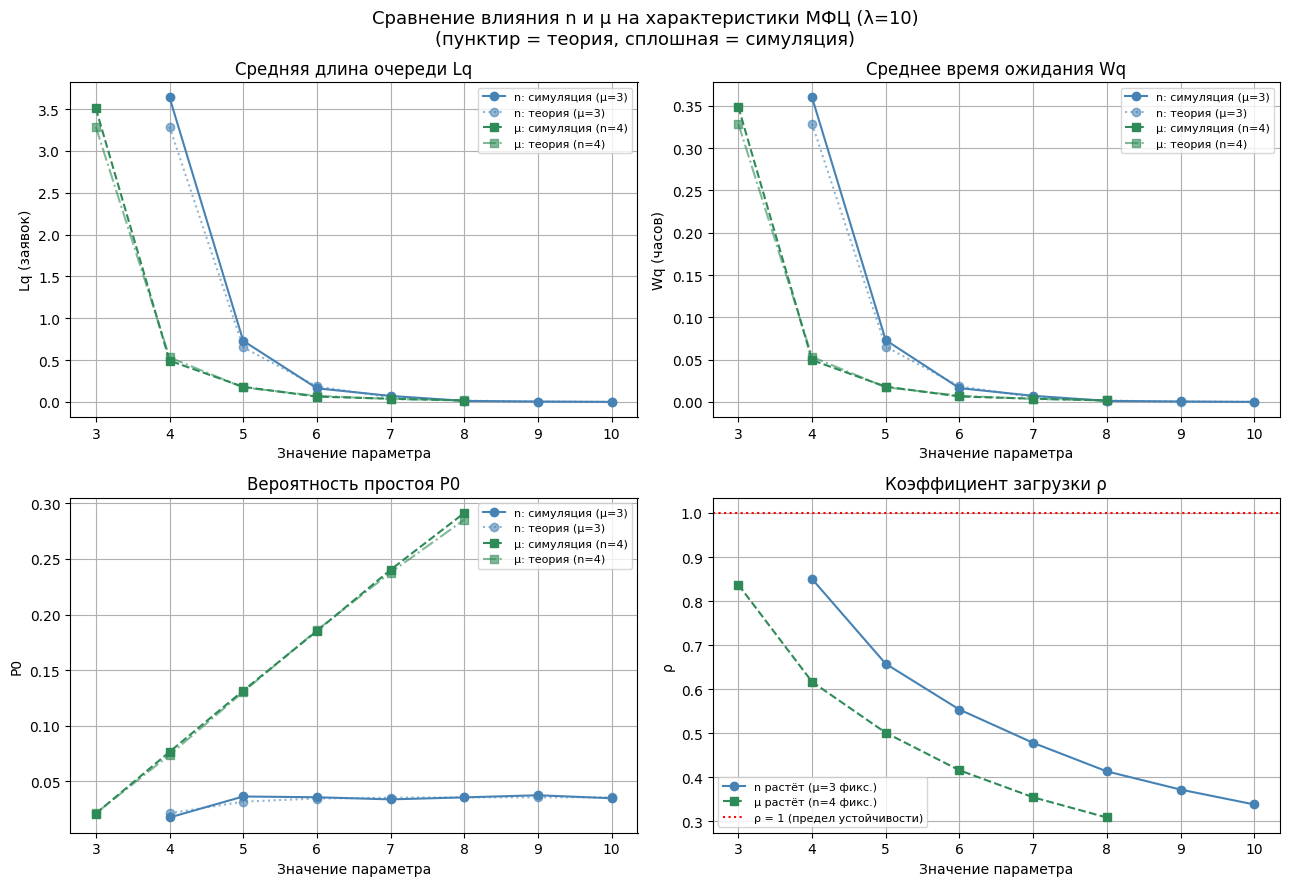

In [10]:
plt.style.use("default")
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Lq от n и μ
ax = axes[0, 0]
ax.plot(df_n["n"],  df_n["Lq"],     marker="o", color="steelblue",  label="n: симуляция (μ=3)")
ax.plot(df_n["n"],  df_n["Lq_th"],  marker="o", color="steelblue",  linestyle=":", alpha=0.6, label="n: теория (μ=3)")
ax.plot(df_mu["μ"], df_mu["Lq"],    marker="s", color="seagreen", linestyle="--", label="μ: симуляция (n=4)")
ax.plot(df_mu["μ"], df_mu["Lq_th"], marker="s", color="seagreen", linestyle="-.", alpha=0.6, label="μ: теория (n=4)")
ax.set_title("Средняя длина очереди Lq")
ax.set_xlabel("Значение параметра")
ax.set_ylabel("Lq (заявок)")
ax.legend(fontsize=8); ax.grid(True)

# Wq от n и μ
ax = axes[0, 1]
ax.plot(df_n["n"],  df_n["Wq, ч"],    marker="o", color="steelblue",  label="n: симуляция (μ=3)")
ax.plot(df_n["n"],  df_n["Wq_th, ч"], marker="o", color="steelblue",  linestyle=":", alpha=0.6, label="n: теория (μ=3)")
ax.plot(df_mu["μ"], df_mu["Wq, ч"],   marker="s", color="seagreen", linestyle="--", label="μ: симуляция (n=4)")
ax.plot(df_mu["μ"], df_mu["Wq_th, ч"],marker="s", color="seagreen", linestyle="-.", alpha=0.6, label="μ: теория (n=4)")
ax.set_title("Среднее время ожидания Wq")
ax.set_xlabel("Значение параметра")
ax.set_ylabel("Wq (часов)")
ax.legend(fontsize=8); ax.grid(True)

# P0 от n и μ
ax = axes[1, 0]
ax.plot(df_n["n"],  df_n["P0"],    marker="o", color="steelblue",  label="n: симуляция (μ=3)")
ax.plot(df_n["n"],  df_n["P0_th"], marker="o", color="steelblue",  linestyle=":", alpha=0.6, label="n: теория (μ=3)")
ax.plot(df_mu["μ"], df_mu["P0"],   marker="s", color="seagreen", linestyle="--", label="μ: симуляция (n=4)")
ax.plot(df_mu["μ"], df_mu["P0_th"],marker="s", color="seagreen", linestyle="-.", alpha=0.6, label="μ: теория (n=4)")
ax.set_title("Вероятность простоя P0")
ax.set_xlabel("Значение параметра")
ax.set_ylabel("P0")
ax.legend(fontsize=8); ax.grid(True)

# ρ от n и μ (тут теории нет — ρ считается из симуляции)
ax = axes[1, 1]
ax.plot(df_n["n"],  df_n["ρ"],  marker="o", color="steelblue",  label="n растёт (μ=3 фикс.)")
ax.plot(df_mu["μ"], df_mu["ρ"], marker="s", color="seagreen", linestyle="--", label="μ растёт (n=4 фикс.)")
ax.axhline(y=1.0, color="red", linestyle=":", label="ρ = 1 (предел устойчивости)")
ax.set_title("Коэффициент загрузки ρ")
ax.set_xlabel("Значение параметра")
ax.set_ylabel("ρ")
ax.legend(fontsize=8); ax.grid(True)

plt.suptitle("Сравнение влияния n и μ на характеристики МФЦ (λ=10)\n(пунктир = теория, сплошная = симуляция)", fontsize=13)
plt.tight_layout()
plt.show()

### Анализ результатов

#### Базовые параметры (λ=10, μ=3, n=4)

Загрузка канала ρ = λ/(n·μ) = 10/12 ≈ 0.84 — система работает вблизи насыщения.
P0 = 0.02: зал полностью пустой лишь 2% рабочего времени.
P_wait = 0.67: двое из трёх посетителей садятся ждать.
Wq ≈ 21 мин при времени обслуживания 1/μ = 20 мин —
посетитель тратит на ожидание столько же, сколько на сам приём.
Это неприемлемо с точки зрения качества сервиса.

#### Влияние числа сотрудников n (μ=3 фиксировано)

Зависимость Lq и Wq от n резко нелинейна — характерная черта систем вблизи насыщения.
Переход с 4 на 5 сотрудников снижает среднюю очередь с 3.5 до 0.6 заявок, то есть в 5–6 раз.
Это эффект «точки насыщения»: при ρ близком к 1 даже небольшое увеличение ёмкости
кардинально меняет поведение системы. При n ≥ 7 очередь и ожидание стремятся к нулю.

При этом вероятность простоя P0 растёт с ростом n крайне медленно и остаётся
низкой (≤ 0.04 при n до 10). Причина в том, что здесь конкурируют два эффекта:
каждый канал в отдельности становится свободен чаще, однако событие «все каналы
свободны одновременно» требует совпадения простоя всё большего числа сотрудников —
это экспоненциально редкое событие. В результате два эффекта почти компенсируют
друг друга, и P0 почти не меняется. Иными словами, даже при n=10 кто-то
из сотрудников почти всегда занят — простоя персонала фактически нет.

#### Влияние интенсивности обслуживания μ (n=4 фиксировано)

Кривые Lq и Wq от μ качественно похожи на кривые от n — та же выпуклая форма
с резким падением в начале. Однако кривая μ падает быстрее: уже при μ=4
очередь сопоставима с n=6 по кривой n. Это объясняется тем, что рост μ
одновременно снижает и нагрузку a = λ/μ (меньше «работы» в единицу времени),
и загрузку ρ = λ/(nμ) — двойной эффект против одинарного у n.

Принципиальное отличие — в поведении P0. При росте μ вероятность простоя
растёт монотонно и почти линейно: от 0.02 при μ=3 до 0.29 при μ=8.
Те же четыре сотрудника обслуживают быстрее, чаще оказываются свободны,
и всё легче застать всех четырёх незанятыми одновременно. При μ=8
почти треть рабочего времени все сотрудники простаивают.

### а что делать в реальном мфц

**Простой сотрудника** — прямые издержки: зарплата выплачивается вне зависимости
от загрузки. При μ=8 и n=4 сотрудники простаивают 29% времени — почти треть
фонда оплаты труда тратится впустую. Нанять пятого сотрудника при уже недозагруженных
четырёх — ещё хуже.

**Ожидание клиента** — люди вынуждены
приходить, альтернативы мфц нет

Ускорение обслуживания (рост μ) выглядит привлекательно на графиках Lq и Wq,
но за счёт роста P0 означает, что сотрудники простаивают всё больше —
платим за скорость деньгами.
Добавление канала (рост n) почти не увеличивает простой (P0 почти не растёт),
но даёт резкое снижение очереди при переходе через точку насыщения.


Оптимальное решение — **добавить одно окно (n=5)** при сохранении μ=3:
- ρ снижается с 0.84 до 0.67
- Wq сокращается с 21 до ~4 минут
- P0 остаётся низкой (~0.03) — сотрудники не простаивают, бюджет не тратится впустую
- Каждый дополнительный сотрудник сверх пяти даёт всё меньший эффект
  для клиента при том же росте затрат

Ускорение обслуживания (μ > 3) оправдано только если оно достигается
организационными мерами без роста стоимости — например, упрощением форм
или предварительной записью, снижающей время приёма. Если это требует
дополнительных затрат, выгоднее открыть пятое окно.